Importing all needed libraries

In [1]:
import os
import torch
import numpy as np
import pandas as pd
from PIL import Image

We need to know what we're dealing with, so print content of folders

In [2]:
os.listdir("images")[:5]

['20250831_095308_jpg.rf.a8d9c753c17680a87a30f67baebe171e.jpg',
 '20250831_095323_jpg.rf.270a42048d15938c3e5b976bc86906e5.jpg',
 '20250831_095340_jpg.rf.d85ec6db0675dbae360b59a1042db151.jpg',
 '20250831_095351_jpg.rf.335dce0a025b0b2ad938aaa486240772.jpg',
 '20250831_095422_jpg.rf.897c95adeead362cc073bedfa9d037e7.jpg']

In [3]:
os.listdir("labels")[:5]

['20250831_095308_jpg.rf.a8d9c753c17680a87a30f67baebe171e.txt',
 '20250831_095323_jpg.rf.270a42048d15938c3e5b976bc86906e5.txt',
 '20250831_095340_jpg.rf.d85ec6db0675dbae360b59a1042db151.txt',
 '20250831_095351_jpg.rf.335dce0a025b0b2ad938aaa486240772.txt',
 '20250831_095422_jpg.rf.897c95adeead362cc073bedfa9d037e7.txt']

Okay so check what is in photo and text file

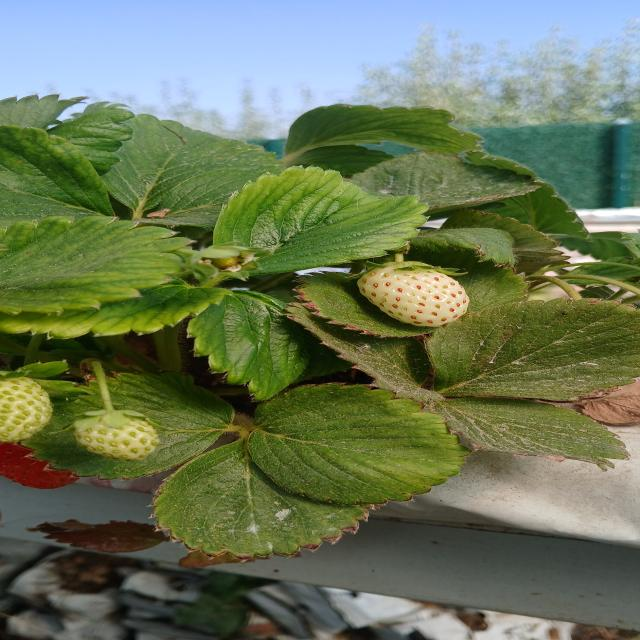

In [4]:
Image.open("images/20250831_095308_jpg.rf.a8d9c753c17680a87a30f67baebe171e.jpg")

In [5]:
with open("labels/20250831_095308_jpg.rf.a8d9c753c17680a87a30f67baebe171e.txt") as f:
    print(f.read())

0 0 0.7416666671875001 0.010084925 0.746813725 0.016454353125 0.7485294125 0.0217622078125 0.7524509796875 0.0286624203125 0.7539215687499999 0.0371549890625 0.7583333328124999 0.0562632703125 0.7625 0.0636942671875 0.763725490625 0.0817409765625 0.7634803921875 0.09872611406250001 0.759803921875 0.115711253125 0.753431371875 0.12367303593750001 0.748039215625 0.115711253125 0.740196078125 0.11464968125 0.7360294125 0.11146496875 0.7352941171875 0.093418259375 0.7352941171875 0.081210190625 0.7318627453125 0.07696390625 0.7294117640625 0.0732484078125 0.7220588234374999 0.0578556265625 0.7176470593750001 0.0536093421875 0.7147058828125 0.048832271875 0.709068628125 0.0525477703125 0.7046568625 0.02919320625 0.6943627453125 0.00530785625 0.6919117640625 0 0.69289215625 0 0.7416666671875001
2 0.1183651796875 0.6852941171875 0.125796178125 0.694117646875 0.138004246875 0.7029411765625 0.1417197453125 0.7029411765625 0.153397028125 0.7088235296875001 0.1809978765625 0.7169117640625 0.19214

Okay that dataset contain 1 photo and labels for all strawberries on it. The labels contain points for outline, but we need to get only boxes. 

In [6]:
from torch.utils.data import Dataset, DataLoader
class StrawberryDataset(Dataset):
    def __init__(self, img_dir, label_dir, transforms=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transforms = transforms
        self.img_files = sorted([f[:-4] for f in os.listdir(img_dir) if f.endswith('.jpg')])
    
    def __len__(self):
        return len(self.img_files)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx] + '.jpg')
        label_path = os.path.join(self.label_dir, self.img_files[idx] + '.txt')

        img = Image.open(img_path)
        width, height = img.size

        labels = []
        boxes = []

        with open(label_path) as f:
            for line in f:
                data = list(map(float, line.split()))
                
                class_id = int(data[0])

                coords = data[1:]

                xs = coords[0::2]
                ys = coords[1::2]

                xmin = min(xs) * width
                xmax = max(xs) * width 

                ymin = min(ys) * height
                ymax = max(ys) * height

                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(class_id+1)
        target = {"boxes": torch.as_tensor(boxes, dtype=torch.float32), "labels": torch.as_tensor(labels, dtype=torch.long)}
        if self.transforms:
            img = self.transforms(img)

        return img, target

In [7]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictors = FastRCNNPredictor(in_features, 4)

In [ ]:
from torchvision import transforms

data_transforms = transforms.Compose([transforms.Resize((640, 640)), transforms.ToTensor()])
dataset = StrawberryDataset("images", "labels", data_transforms)
dataloader = DataLoader(dataset, 3, True, collate_fn=lambda x: tuple(zip(*x)))

device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=5e-3, momentum=0.9, weight_decay=5e-4)

model.train()
for images, targets in dataloader:
    images = list(image.to(device) for image in images)
    targets = [{k: v.to(device) for k, v in t.items()}  for t in targets]
    
    loss_dict = model(images, targets)
    losses = sum(loss for loss in loss_dict.values())

    optimizer.zero_grad()
    losses.backward()
    optimizer.step()

    print(f"Loss: {losses.item()}")

Loss: 1.1109944581985474
Loss: 1.7029085159301758
Loss: 0.3839174807071686
Loss: 1.3576499223709106
Loss: 0.6105211973190308
Loss: 0.3026917278766632
Loss: 0.3488524258136749
Loss: 0.33303993940353394
Loss: 0.6270982623100281
Loss: 0.5452583432197571
Loss: 0.49300485849380493
Loss: 0.5731475353240967
Loss: 0.6884065866470337
Loss: 0.7385967373847961
Loss: 0.27175962924957275
Loss: 0.29543569684028625
Loss: 0.30765265226364136
Loss: 0.21841569244861603
Loss: 0.12907782196998596
Loss: 0.24444156885147095
Loss: 0.14017342031002045
Loss: 0.7723314762115479
Loss: 0.7407021522521973
Loss: 0.5269734859466553
Loss: 0.6150603890419006
Loss: 0.5311801433563232
Loss: 1.3743834495544434
Loss: 0.5616468191146851
Loss: 0.26314833760261536
Loss: 0.13192784786224365
Loss: 0.38613593578338623
Loss: 1.3142387866973877
Loss: 0.8115946054458618
Loss: 0.3115333318710327
Loss: 0.46160420775413513
Loss: 0.2742392420768738
Loss: 0.2215346097946167
Loss: 2.4654176235198975
Loss: 0.3051331043243408
Loss: 0.4200

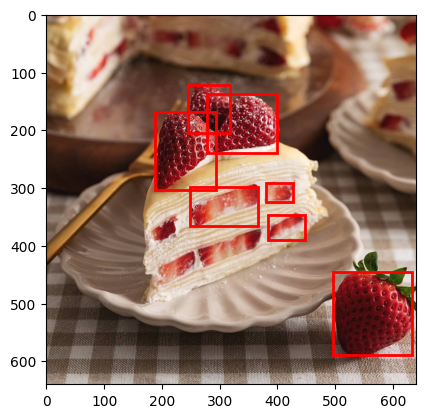

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_prediction(model, img_path, threshold=0.5):
    model.eval()
    img = Image.open(img_path).convert("RGB")
    img = img.resize((640, 640), Image.LANCZOS)
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        prediction = model(img_tensor)

    fig, ax = plt.subplots(1)
    ax.imshow(img)

    for i, score in enumerate(prediction[0]['scores']):
        if score > threshold:
            box = prediction[0]['boxes'][i].cpu().numpy()
            label = prediction[0]['labels'][i].cpu().item()

            color = 'r' if label == 1 else 'y' if label == 2 else 'g'

            rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], 
                                     linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)

    plt.show()

visualize_prediction(model, 'image.jpg')